# 07 Supervised Model Training and Evaluation

## Objective

This notebook trains and evaluates supervised classification models to predict whether a customer responds to the most recent marketing campaign (`response`).

The main research question is: **does the unsupervised cluster label add predictive value?**

To answer that, models are trained under controlled feature sets:

- **Feature Set A:** baseline customer features without clusters or campaign history.
- **Feature Set B:** Feature Set A plus the `cluster` label.
- **Feature Set C:** Feature Set B plus summarized historical campaign behavior.

This notebook does not perform clustering again, redefine the target, tune models extensively, deploy a model, or claim causal relationships.

## Setup

The reusable training workflow lives in `src/model_training.py`. Preprocessing is handled inside scikit-learn pipelines so the test data does not leak into fitted preprocessing steps.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from model_training import (
    FEATURE_SETS,
    FEATURE_SET_COMPARISON_PATH,
    MODEL_EVALUATION_PATH,
    MODELING_DATA_PATH,
    TARGET_COLUMN,
    TEST_SIZE,
    RANDOM_STATE,
    compare_feature_sets,
    create_classification_report_df,
    define_feature_sets,
    evaluate_thresholds,
    get_curve_data,
    get_model_interpretation_table,
    get_positive_scores,
    identify_feature_types,
    load_modeling_data,
    make_train_test_split,
    save_evaluation_outputs,
    select_best_model,
    train_and_evaluate_models,
    validate_modeling_data,
)

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 160)

print(f"Modeling data path: {MODELING_DATA_PATH}")
print(f"Evaluation summary path: {MODEL_EVALUATION_PATH}")
print(f"Feature-set comparison path: {FEATURE_SET_COMPARISON_PATH}")

Modeling data path: /Users/arjun/Documents/Intro DS final/data/processed/modeling_data.csv
Evaluation summary path: /Users/arjun/Documents/Intro DS final/reports/model_evaluation_summary.csv
Feature-set comparison path: /Users/arjun/Documents/Intro DS final/reports/feature_set_comparison_summary.csv


## 1. Load and Inspect Modeling Data

Confirm that the modeling dataset has the expected target, no missing values, no infinite values, and identifiable categorical/numerical columns.

In [2]:
df = load_modeling_data(MODELING_DATA_PATH)
validation = validate_modeling_data(df)

print(f"Modeling dataset shape: {df.shape}")
display(pd.Series(validation, name="count").to_frame())
display(df.head())

Modeling dataset shape: (2213, 32)


,count
rows,2213
columns,32
missing_values,0
infinite_values,0
positive_count,333
negative_count,1880


,education,marital_status,cluster,age,income,children_total,has_children,household_size,customer_tenure_days,customer_tenure_years,recency,complain,total_spending,wine_share,fruits_share,meat_share,fish_share,sweets_share,gold_share,luxury_spending_ratio,spending_per_tenure_year,total_purchases,total_store_web_catalog_purchases,web_purchase_share,store_purchase_share,catalog_purchase_share,deal_purchase_share,average_spend_per_purchase,num_web_visits_month,total_campaign_acceptances,any_campaign_acceptance,response
0,Graduation,Single,0,57,58138.0,0,0,1,663,1.815195,58,0,1617,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.447124,890.813348,25,22,0.363636,0.181818,0.454545,0.120000,73.500000,7,0,0,1
1,Graduation,Single,3,60,46344.0,2,1,3,113,0.309377,38,0,27,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.629630,87.272124,6,4,0.250000,0.500000,0.250000,0.333333,6.750000,5,0,0,0
2,Graduation,Together,0,49,71613.0,0,0,2,312,0.854209,26,0,776,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.603093,908.442308,21,20,0.400000,0.500000,0.100000,0.047619,38.800000,4,0,0,0
3,Graduation,Together,1,30,26646.0,1,1,3,139,0.380561,26,0,53,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.301887,139.267986,8,6,0.333333,0.666667,0.000000,0.250000,8.833333,6,0,0,0
4,PhD,Married,0,33,58293.0,1,1,3,161,0.440794,94,0,422,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.445498,957.363354,19,14,0.357143,0.428571,0.214286,0.263158,30.142857,5,0,0,0


In [3]:
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_pct = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100
target_table = pd.DataFrame({"count": target_counts, "pct": target_pct.round(2)})

display(target_table)
print(f"Majority-class baseline accuracy: {target_pct.max() / 100:.4f}")

all_feature_names = [column for column in df.columns if column != TARGET_COLUMN]
numeric_features_all, categorical_features_all = identify_feature_types(df, all_feature_names)

print("Categorical columns available:")
print(categorical_features_all)
print("\nNumerical columns available:")
print(numeric_features_all)

,count,pct
response,,
0,1880,84.95
1,333,15.05


Majority-class baseline accuracy: 0.8495
Categorical columns available:
['education', 'marital_status', 'cluster']

Numerical columns available:
['age', 'income', 'children_total', 'has_children', 'household_size', 'customer_tenure_days', 'customer_tenure_years', 'recency', 'complain', 'total_spending', 'wine_share', 'fruits_share', 'meat_share', 'fish_share', 'sweets_share', 'gold_share', 'luxury_spending_ratio', 'spending_per_tenure_year', 'total_purchases', 'total_store_web_catalog_purchases', 'web_purchase_share', 'store_purchase_share', 'catalog_purchase_share', 'deal_purchase_share', 'average_spend_per_purchase', 'num_web_visits_month', 'total_campaign_acceptances', 'any_campaign_acceptance']


**Class imbalance:** The positive response class is only about 15% of the dataset. Accuracy can be misleading because a model that always predicts `0` is already about 85% accurate. The main comparison emphasizes PR-AUC, ROC-AUC, positive-class F1, precision, and recall.

## 2. Controlled Feature Sets

Feature Set A excludes both cluster and historical campaign summaries. Feature Set B adds only the cluster label to test whether segmentation helps. Feature Set C adds summarized historical campaign behavior.

In [4]:
feature_sets = define_feature_sets()

for feature_set_name, feature_names in feature_sets.items():
    numerical_features, categorical_features = identify_feature_types(df, feature_names)
    print(f"{feature_set_name}")
    print(f"  Total features: {len(feature_names)}")
    print(f"  Numerical features: {len(numerical_features)}")
    print(f"  Categorical features: {len(categorical_features)}")
    print(f"  Features: {feature_names}")
    print("-" * 100)

A_baseline_customer_features
  Total features: 28
  Numerical features: 26
  Categorical features: 2
  Features: ['education', 'marital_status', 'age', 'income', 'children_total', 'has_children', 'household_size', 'customer_tenure_days', 'customer_tenure_years', 'recency', 'complain', 'total_spending', 'wine_share', 'fruits_share', 'meat_share', 'fish_share', 'sweets_share', 'gold_share', 'luxury_spending_ratio', 'spending_per_tenure_year', 'total_purchases', 'total_store_web_catalog_purchases', 'web_purchase_share', 'store_purchase_share', 'catalog_purchase_share', 'deal_purchase_share', 'average_spend_per_purchase', 'num_web_visits_month']
----------------------------------------------------------------------------------------------------
B_baseline_plus_cluster
  Total features: 29
  Numerical features: 26
  Categorical features: 3
  Features: ['education', 'marital_status', 'age', 'income', 'children_total', 'has_children', 'household_size', 'customer_tenure_days', 'customer_tenure

## 3. Shared Train/Test Split

All feature sets and models use the same stratified 80/20 split (`test_size=0.20`, `random_state=42`). This keeps comparisons fair.

In [5]:
split_data = make_train_test_split(df)

train_distribution = pd.DataFrame({
    "count": split_data.y_train.value_counts().sort_index(),
    "pct": (split_data.y_train.value_counts(normalize=True).sort_index() * 100).round(2),
})
test_distribution = pd.DataFrame({
    "count": split_data.y_test.value_counts().sort_index(),
    "pct": (split_data.y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})

print(f"Train size: {len(split_data.y_train)}")
display(train_distribution)
print(f"Test size: {len(split_data.y_test)}")
display(test_distribution)

Train size: 1770


,count,pct
response,,
0,1504,84.97
1,266,15.03


Test size: 443


,count,pct
response,,
0,376,84.88
1,67,15.12


## 4. Preprocessing and Models

Preprocessing is inside each model pipeline:

- Numeric features: median imputation, then standard scaling.
- Categorical features: most-frequent imputation, then one-hot encoding with unknown-category handling.
- `cluster` is treated as categorical, not continuous numeric.

Models trained for each feature set:

- DummyClassifier majority baseline
- Logistic Regression
- Logistic Regression with `class_weight="balanced"`
- Random Forest
- Random Forest with `class_weight="balanced"`
- Gradient Boosting

In [6]:
evaluation_df, fitted_pipelines = train_and_evaluate_models(df, split_data)
feature_set_comparison_df = compare_feature_sets(evaluation_df)
save_evaluation_outputs(evaluation_df, feature_set_comparison_df)

display(evaluation_df)
display(feature_set_comparison_df)

,feature_set,model_name,accuracy,precision_positive,recall_positive,f1_positive,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,notes
0,A_baseline_customer_features,Dummy Majority,0.848758,0.000000,0.000000,0.000000,0.500000,0.151242,376,0,67,0,Majority-class baseline.
1,A_baseline_customer_features,Logistic Regression,0.860045,0.571429,0.298507,0.392157,0.872043,0.485120,361,15,47,20,Scaled linear classifier without class weighting.
2,A_baseline_customer_features,Logistic Regression Balanced,0.794582,0.411765,0.835821,0.551724,0.875933,0.485697,296,80,11,56,Scaled linear classifier with class_weight='ba...
3,A_baseline_customer_features,Random Forest,0.855530,0.636364,0.104478,0.179487,0.866604,0.508393,372,4,60,7,Tree ensemble without class weighting.
4,A_baseline_customer_features,Random Forest Balanced,0.857788,0.533333,0.477612,0.503937,0.867081,0.548583,348,28,35,32,Tree ensemble with class_weight='balanced'.
5,A_baseline_customer_features,Gradient Boosting,0.871332,0.666667,0.298507,0.412371,0.863429,0.575303,366,10,47,20,Gradient boosting classifier; no class weighting.
6,B_baseline_plus_cluster,Dummy Majority,0.848758,0.000000,0.000000,0.000000,0.500000,0.151242,376,0,67,0,Majority-class baseline.
7,B_baseline_plus_cluster,Logistic Regression,0.860045,0.571429,0.298507,0.392157,0.870772,0.482613,361,15,47,20,Scaled linear classifier without class weighting.
8,B_baseline_plus_cluster,Logistic Regression Balanced,0.794582,0.410448,0.820896,0.547264,0.875655,0.483054,297,79,12,55,Scaled linear classifier with class_weight='ba...
9,B_baseline_plus_cluster,Random Forest,0.855530,0.636364,0.104478,0.179487,0.868391,0.512799,372,4,60,7,Tree ensemble without class weighting.


,feature_set,best_model_for_feature_set,accuracy,precision_positive,recall_positive,f1_positive,roc_auc,pr_auc,interpretation
0,A_baseline_customer_features,Gradient Boosting,0.871332,0.666667,0.298507,0.412371,0.863429,0.575303,"Baseline using customer demographics, relation..."
1,B_baseline_plus_cluster,Gradient Boosting,0.871332,0.666667,0.298507,0.412371,0.863151,0.562844,Tests whether the unsupervised cluster label i...
2,C_full_with_campaign_history,Logistic Regression Balanced,0.821670,0.449153,0.791045,0.572973,0.906339,0.631201,Adds summarized historical campaign behavior; ...


## 5. Model Evaluation Comparison

The table below contains one row per model/feature-set combination. Because the target is imbalanced, PR-AUC and positive-class F1/recall are especially important.

,feature_set,model_name,accuracy,precision_positive,recall_positive,f1_positive,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,notes
14,C_full_with_campaign_history,Logistic Regression Balanced,0.821670,0.449153,0.791045,0.572973,0.906339,0.631201,311,65,14,53,Scaled linear classifier with class_weight='ba...
13,C_full_with_campaign_history,Logistic Regression,0.878104,0.651163,0.417910,0.509091,0.903362,0.630378,361,15,39,28,Scaled linear classifier without class weighting.
17,C_full_with_campaign_history,Gradient Boosting,0.887133,0.717949,0.417910,0.528302,0.893518,0.611742,365,11,39,28,Gradient boosting classifier; no class weighting.
16,C_full_with_campaign_history,Random Forest Balanced,0.864560,0.559322,0.492537,0.523810,0.878473,0.584194,350,26,34,33,Tree ensemble with class_weight='balanced'.
15,C_full_with_campaign_history,Random Forest,0.864560,0.640000,0.238806,0.347826,0.879624,0.577095,367,9,51,16,Tree ensemble without class weighting.
5,A_baseline_customer_features,Gradient Boosting,0.871332,0.666667,0.298507,0.412371,0.863429,0.575303,366,10,47,20,Gradient boosting classifier; no class weighting.
11,B_baseline_plus_cluster,Gradient Boosting,0.871332,0.666667,0.298507,0.412371,0.863151,0.562844,366,10,47,20,Gradient boosting classifier; no class weighting.
10,B_baseline_plus_cluster,Random Forest Balanced,0.841986,0.475410,0.432836,0.453125,0.868073,0.550326,344,32,38,29,Tree ensemble with class_weight='balanced'.
4,A_baseline_customer_features,Random Forest Balanced,0.857788,0.533333,0.477612,0.503937,0.867081,0.548583,348,28,35,32,Tree ensemble with class_weight='balanced'.
9,B_baseline_plus_cluster,Random Forest,0.855530,0.636364,0.104478,0.179487,0.868391,0.512799,372,4,60,7,Tree ensemble without class weighting.


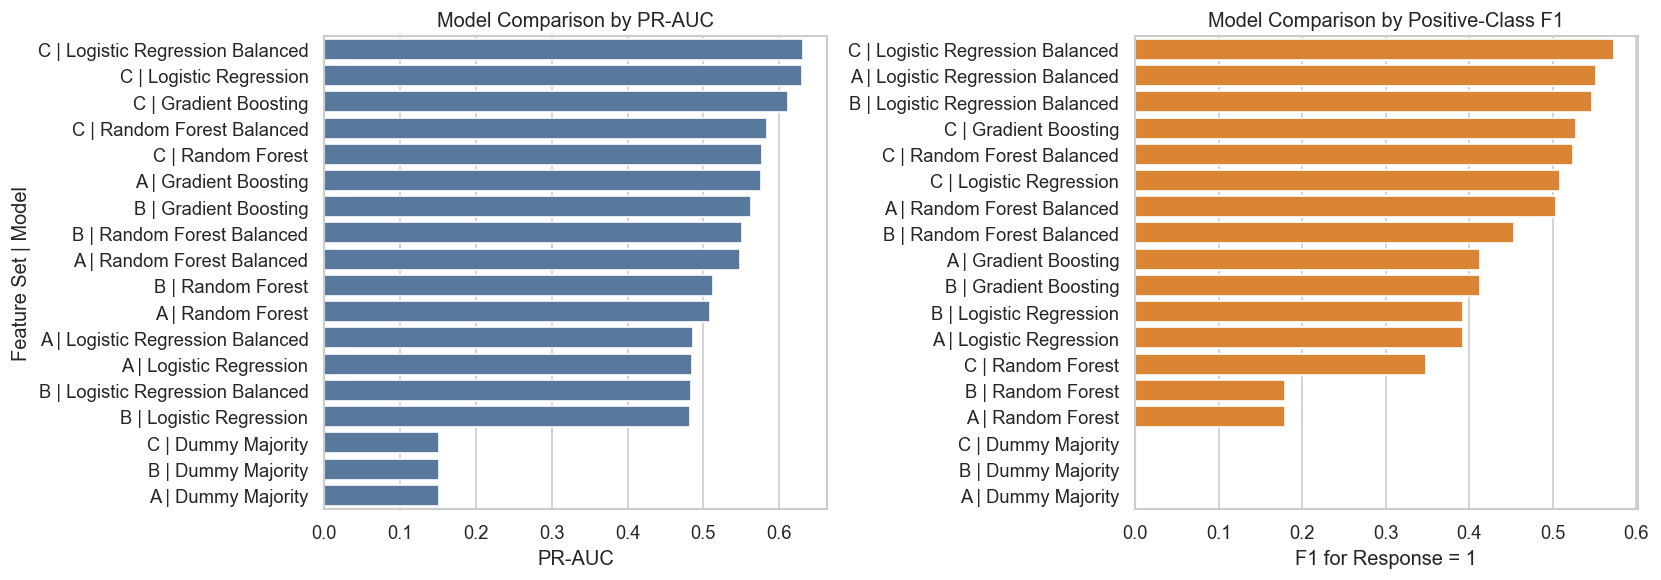

In [7]:
metric_view = evaluation_df.sort_values(["pr_auc", "f1_positive", "roc_auc"], ascending=False)
display(metric_view)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = evaluation_df.copy()
plot_df["model_label"] = plot_df["feature_set"].str[0] + " | " + plot_df["model_name"]
plot_df = plot_df.sort_values("pr_auc", ascending=False)

sns.barplot(data=plot_df, y="model_label", x="pr_auc", ax=axes[0], color="#4C78A8")
axes[0].set_title("Model Comparison by PR-AUC")
axes[0].set_xlabel("PR-AUC")
axes[0].set_ylabel("Feature Set | Model")

plot_df_f1 = evaluation_df.copy()
plot_df_f1["model_label"] = plot_df_f1["feature_set"].str[0] + " | " + plot_df_f1["model_name"]
plot_df_f1 = plot_df_f1.sort_values("f1_positive", ascending=False)
sns.barplot(data=plot_df_f1, y="model_label", x="f1_positive", ax=axes[1], color="#F58518")
axes[1].set_title("Model Comparison by Positive-Class F1")
axes[1].set_xlabel("F1 for Response = 1")
axes[1].set_ylabel("")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_comparison_pr_auc_f1.png", bbox_inches="tight")
plt.show()

## 6. Feature Set Comparison

This comparison directly answers the controlled feature-set questions:

- Does adding `cluster` improve performance from Feature Set A to B?
- Does adding historical campaign summaries improve performance from Feature Set B to C?

,feature_set,best_model_for_feature_set,accuracy,precision_positive,recall_positive,f1_positive,roc_auc,pr_auc,interpretation
0,A_baseline_customer_features,Gradient Boosting,0.871332,0.666667,0.298507,0.412371,0.863429,0.575303,"Baseline using customer demographics, relation..."
1,B_baseline_plus_cluster,Gradient Boosting,0.871332,0.666667,0.298507,0.412371,0.863151,0.562844,Tests whether the unsupervised cluster label i...
2,C_full_with_campaign_history,Logistic Regression Balanced,0.821670,0.449153,0.791045,0.572973,0.906339,0.631201,Adds summarized historical campaign behavior; ...


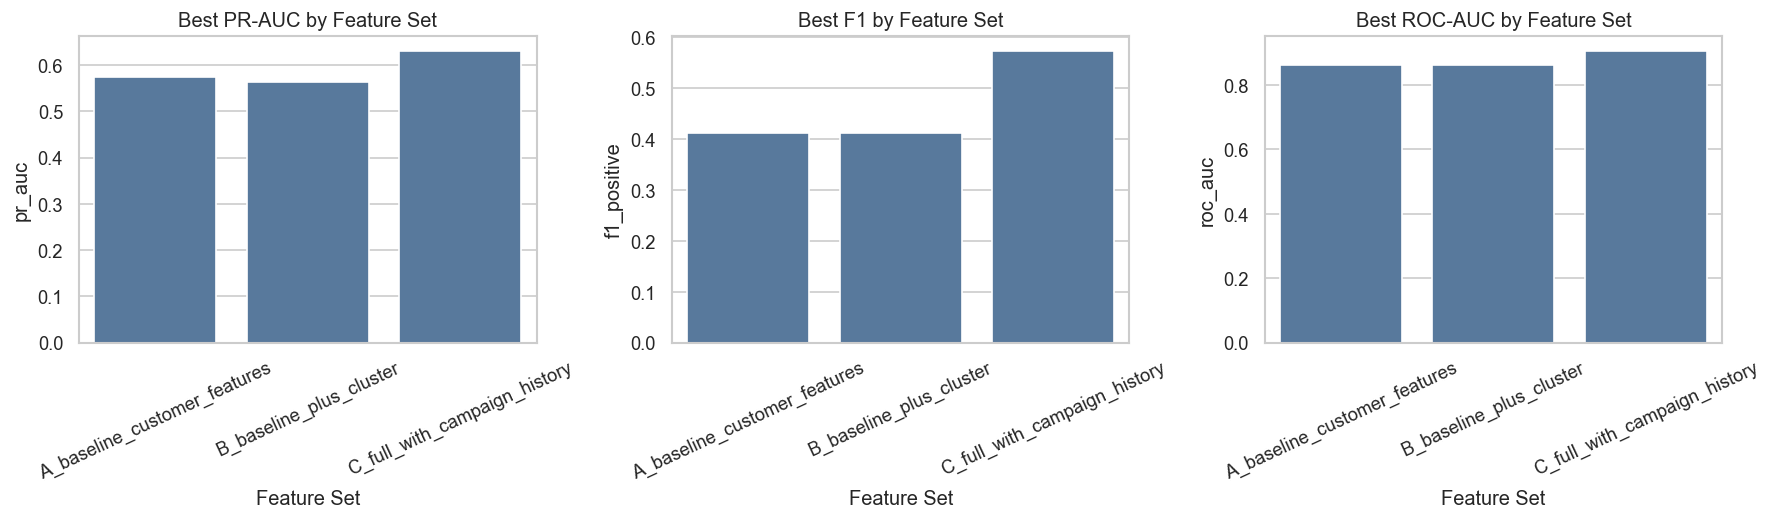

In [8]:
display(feature_set_comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, title in zip(
    axes,
    ["pr_auc", "f1_positive", "roc_auc"],
    ["Best PR-AUC by Feature Set", "Best F1 by Feature Set", "Best ROC-AUC by Feature Set"],
):
    sns.barplot(data=feature_set_comparison_df, x="feature_set", y=metric, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Feature Set")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "feature_set_comparison_metrics.png", bbox_inches="tight")
plt.show()

In [9]:
best_a = feature_set_comparison_df.query("feature_set == 'A_baseline_customer_features'").iloc[0]
best_b = feature_set_comparison_df.query("feature_set == 'B_baseline_plus_cluster'").iloc[0]
best_c = feature_set_comparison_df.query("feature_set == 'C_full_with_campaign_history'").iloc[0]

ab_changes = {
    "pr_auc_change_B_minus_A": best_b["pr_auc"] - best_a["pr_auc"],
    "roc_auc_change_B_minus_A": best_b["roc_auc"] - best_a["roc_auc"],
    "f1_change_B_minus_A": best_b["f1_positive"] - best_a["f1_positive"],
    "recall_change_B_minus_A": best_b["recall_positive"] - best_a["recall_positive"],
    "precision_change_B_minus_A": best_b["precision_positive"] - best_a["precision_positive"],
}
bc_changes = {
    "pr_auc_change_C_minus_B": best_c["pr_auc"] - best_b["pr_auc"],
    "roc_auc_change_C_minus_B": best_c["roc_auc"] - best_b["roc_auc"],
    "f1_change_C_minus_B": best_c["f1_positive"] - best_b["f1_positive"],
    "recall_change_C_minus_B": best_c["recall_positive"] - best_b["recall_positive"],
    "precision_change_C_minus_B": best_c["precision_positive"] - best_b["precision_positive"],
}

print("Change from Feature Set A to B:")
display(pd.Series(ab_changes).to_frame("change"))
print("Change from Feature Set B to C:")
display(pd.Series(bc_changes).to_frame("change"))

Change from Feature Set A to B:


,change
pr_auc_change_B_minus_A,-0.012459
roc_auc_change_B_minus_A,-0.000278
f1_change_B_minus_A,0.000000
recall_change_B_minus_A,0.000000
precision_change_B_minus_A,0.000000


Change from Feature Set B to C:


,change
pr_auc_change_C_minus_B,0.068357
roc_auc_change_C_minus_B,0.043188
f1_change_C_minus_B,0.160602
recall_change_C_minus_B,0.492538
precision_change_C_minus_B,-0.217514


**Feature-set conclusion:** In this experiment, Feature Set B does not outperform Feature Set A. The best A model and best B model have the same F1 and accuracy, while B has slightly lower PR-AUC. This suggests that the cluster label does **not** add meaningful predictive value beyond the underlying customer features.

Feature Set C improves PR-AUC, ROC-AUC, F1, and recall compared with Feature Set B. Historical campaign summaries appear useful for prediction, but they should be described carefully as prior behavioral associations, not causal effects.

## 7. Strongest Models and Classification Reports

Show classification reports for the best model in each feature set.

In [10]:
best_models = {}
for feature_set_name in FEATURE_SETS:
    best_feature_set, best_model_name = select_best_model(evaluation_df, feature_set=feature_set_name)
    best_models[best_feature_set] = best_model_name
    pipeline = fitted_pipelines[(best_feature_set, best_model_name)]
    X_test_subset = split_data.X_test[FEATURE_SETS[best_feature_set]]
    print(f"{best_feature_set}: {best_model_name}")
    display(create_classification_report_df(pipeline, X_test_subset, split_data.y_test))

A_baseline_customer_features: Gradient Boosting


,precision,recall,f1-score,support
0,0.886199,0.973404,0.927757,376.000000
1,0.666667,0.298507,0.412371,67.000000
accuracy,0.871332,0.871332,0.871332,0.871332
macro avg,0.776433,0.635956,0.670064,443.000000
weighted avg,0.852996,0.871332,0.849809,443.000000


B_baseline_plus_cluster: Gradient Boosting


,precision,recall,f1-score,support
0,0.886199,0.973404,0.927757,376.000000
1,0.666667,0.298507,0.412371,67.000000
accuracy,0.871332,0.871332,0.871332,0.871332
macro avg,0.776433,0.635956,0.670064,443.000000
weighted avg,0.852996,0.871332,0.849809,443.000000


C_full_with_campaign_history: Logistic Regression Balanced


,precision,recall,f1-score,support
0,0.956923,0.827128,0.887304,376.00000
1,0.449153,0.791045,0.572973,67.00000
accuracy,0.821670,0.821670,0.821670,0.82167
macro avg,0.703038,0.809086,0.730138,443.00000
weighted avg,0.880127,0.821670,0.839764,443.00000


## 8. Recommended Model and Threshold Analysis

The preferred model for the next project step is the best Feature Set C model by PR-AUC: **Logistic Regression Balanced**. It is not the most accurate model, but it has the strongest PR-AUC and much stronger recall for the minority response class, which matters for campaign-response prediction.

,threshold,precision_positive,recall_positive,f1_positive,false_positives,false_negatives,true_positives,true_negatives
0,0.2,0.3249,0.9552,0.4848,133,3,64,243
1,0.3,0.3728,0.9403,0.5339,106,4,63,270
2,0.4,0.4196,0.8955,0.5714,83,7,60,293
3,0.5,0.4492,0.7910,0.5730,65,14,53,311
4,0.6,0.5000,0.6866,0.5786,46,21,46,330


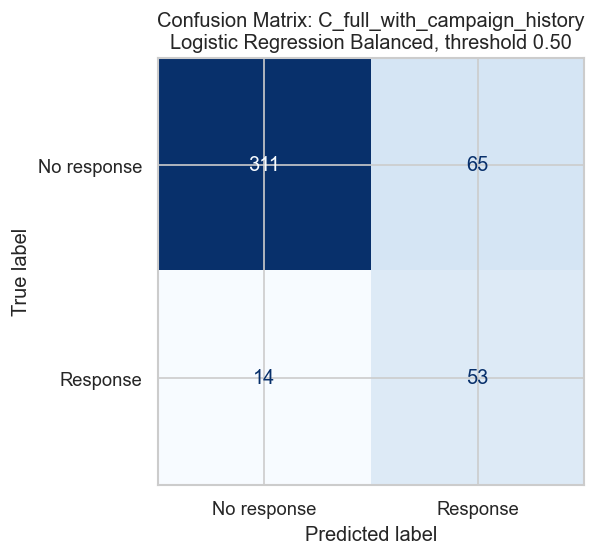

In [11]:
preferred_feature_set = "C_full_with_campaign_history"
preferred_model_name = best_models[preferred_feature_set]
preferred_pipeline = fitted_pipelines[(preferred_feature_set, preferred_model_name)]
preferred_X_test = split_data.X_test[FEATURE_SETS[preferred_feature_set]]
preferred_scores = get_positive_scores(preferred_pipeline, preferred_X_test)

threshold_df = evaluate_thresholds(split_data.y_test, preferred_scores)
display(threshold_df.round(4))

preferred_pred_default = preferred_pipeline.predict(preferred_X_test)
cm = ConfusionMatrixDisplay.from_predictions(
    split_data.y_test,
    preferred_pred_default,
    labels=[0, 1],
    display_labels=["No response", "Response"],
    cmap="Blues",
    colorbar=False,
)
cm.ax_.set_title(f"Confusion Matrix: {preferred_feature_set}\n{preferred_model_name}, threshold 0.50")
cm.figure_.tight_layout()
cm.figure_.savefig(FIGURE_DIR / "recommended_model_confusion_matrix.png", bbox_inches="tight")
plt.show()

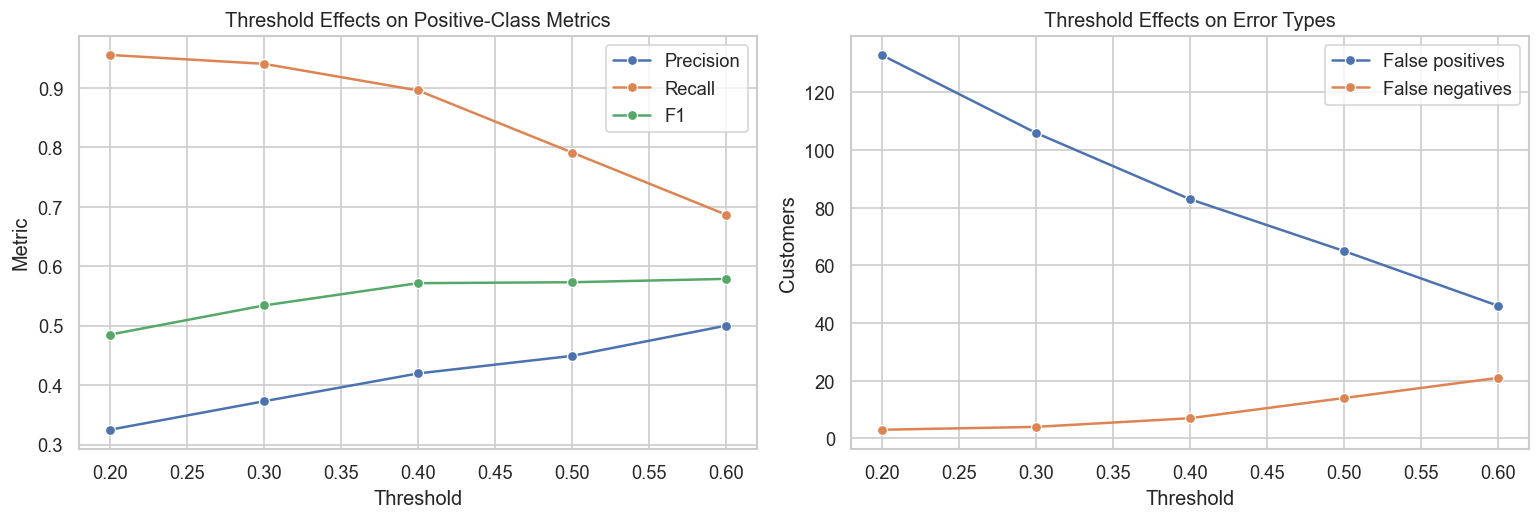

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(data=threshold_df, x="threshold", y="precision_positive", marker="o", label="Precision", ax=axes[0])
sns.lineplot(data=threshold_df, x="threshold", y="recall_positive", marker="o", label="Recall", ax=axes[0])
sns.lineplot(data=threshold_df, x="threshold", y="f1_positive", marker="o", label="F1", ax=axes[0])
axes[0].set_title("Threshold Effects on Positive-Class Metrics")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Metric")

sns.lineplot(data=threshold_df, x="threshold", y="false_positives", marker="o", label="False positives", ax=axes[1])
sns.lineplot(data=threshold_df, x="threshold", y="false_negatives", marker="o", label="False negatives", ax=axes[1])
axes[1].set_title("Threshold Effects on Error Types")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Customers")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "threshold_analysis_recommended_model.png", bbox_inches="tight")
plt.show()

**Threshold tradeoff:** Lower thresholds catch more likely responders but create more false positives. Higher thresholds are more precise but miss more responders. At threshold 0.50, the recommended model catches 53 of 67 responders. At threshold 0.60, precision improves to 0.50 and F1 is slightly higher, but the model misses 21 responders instead of 14. A campaign with low contact cost might prefer a lower threshold; a campaign with limited budget might prefer a higher threshold.

## 9. ROC and Precision-Recall Curves

Plot curves for the strongest model from each feature set.

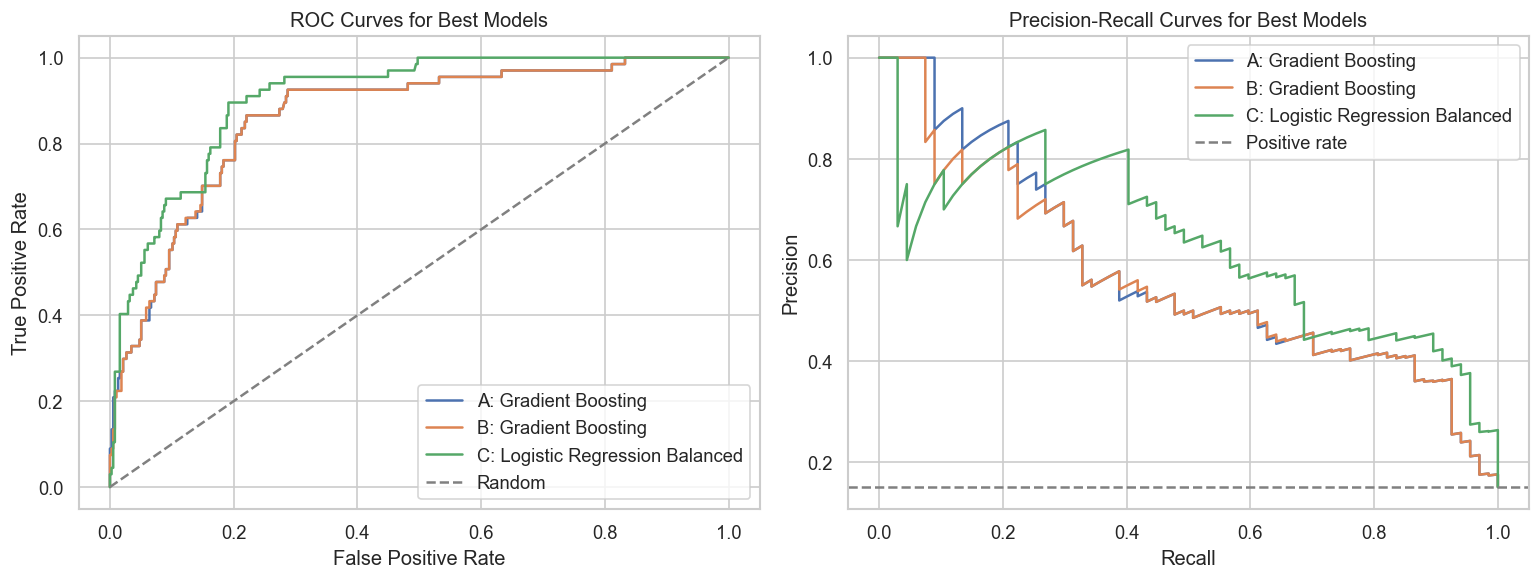

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for feature_set_name, model_name in best_models.items():
    pipeline = fitted_pipelines[(feature_set_name, model_name)]
    X_test_subset = split_data.X_test[FEATURE_SETS[feature_set_name]]
    scores = get_positive_scores(pipeline, X_test_subset)
    roc_df, pr_df = get_curve_data(split_data.y_test, scores)

    label = f"{feature_set_name[0]}: {model_name}"
    axes[0].plot(roc_df["false_positive_rate"], roc_df["true_positive_rate"], label=label)
    axes[1].plot(pr_df["recall"], pr_df["precision"], label=label)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_title("ROC Curves for Best Models")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

baseline_positive_rate = split_data.y_test.mean()
axes[1].axhline(baseline_positive_rate, linestyle="--", color="gray", label="Positive rate")
axes[1].set_title("Precision-Recall Curves for Best Models")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "best_models_roc_pr_curves.png", bbox_inches="tight")
plt.show()

## 10. Feature Importance and Interpretability

These are predictive associations, not causal explanations. For tree-based models, the notebook shows feature importances. For logistic regression, it shows the largest positive and negative coefficients after preprocessing.

In [14]:
interpretation_tables = {}
for feature_set_name, model_name in best_models.items():
    pipeline = fitted_pipelines[(feature_set_name, model_name)]
    interpretation = get_model_interpretation_table(pipeline, top_n=20)
    interpretation_tables[feature_set_name] = interpretation
    print(f"{feature_set_name}: {model_name}")
    display(interpretation)

    cluster_rows = interpretation[
        interpretation.get("feature", pd.Series(dtype=str)).astype(str).str.contains("cluster", case=False, regex=False)
    ]
    if not cluster_rows.empty:
        print("Cluster-related rows in top features:")
        display(cluster_rows)

A_baseline_customer_features: Gradient Boosting


,feature,importance
0,recency,0.145284
1,store_purchase_share,0.134446
2,income,0.081132
3,total_spending,0.076381
4,household_size,0.073477
5,customer_tenure_days,0.072294
6,average_spend_per_purchase,0.053792
7,customer_tenure_years,0.043934
8,gold_share,0.039905
9,meat_share,0.032839


B_baseline_plus_cluster: Gradient Boosting


,feature,importance
0,recency,0.145186
1,store_purchase_share,0.133617
2,income,0.080616
3,total_spending,0.077125
4,household_size,0.073477
5,customer_tenure_years,0.068742
6,average_spend_per_purchase,0.054067
7,customer_tenure_days,0.046923
8,gold_share,0.039881
9,deal_purchase_share,0.031209


C_full_with_campaign_history: Logistic Regression Balanced


,feature,coefficient,abs_coefficient
0,education_PhD,1.273181,1.273181
1,education_Basic,-1.207790,1.207790
2,total_campaign_acceptances,1.157296,1.157296
3,recency,-1.053496,1.053496
4,catalog_purchase_share,1.004925,1.004925
5,web_purchase_share,0.808937,0.808937
6,marital_status_Together,-0.582202,0.582202
7,customer_tenure_years,0.569572,0.569572
8,customer_tenure_days,0.569572,0.569572
9,marital_status_YOLO,-0.537263,0.537263


In [15]:
# Explicitly inspect cluster features in Feature Set B and C, even if they are not top-ranked.
b_pipeline = fitted_pipelines[("B_baseline_plus_cluster", best_models["B_baseline_plus_cluster"])]
b_all_importance = get_model_interpretation_table(b_pipeline, top_n=100)
b_cluster_rows = b_all_importance[
    b_all_importance["feature"].astype(str).str.contains("cluster", case=False, regex=False)
]
print("Feature Set B cluster-related importance/coefficient rows:")
display(b_cluster_rows)

c_pipeline = fitted_pipelines[("C_full_with_campaign_history", best_models["C_full_with_campaign_history"])]
c_all_importance = get_model_interpretation_table(c_pipeline, top_n=100)
c_cluster_campaign_rows = c_all_importance[
    c_all_importance["feature"].astype(str).str.contains("cluster|campaign", case=False, regex=True)
]
print("Feature Set C cluster/campaign-related coefficient rows:")
display(c_cluster_campaign_rows)

Feature Set B cluster-related importance/coefficient rows:


,feature,importance
31,cluster_0,0.0
32,cluster_1,0.0
33,cluster_2,0.0
42,cluster_3,0.0


Feature Set C cluster/campaign-related coefficient rows:


,feature,coefficient,abs_coefficient
2,total_campaign_acceptances,1.157296,1.157296
29,cluster_0,-0.229916,0.229916
34,any_campaign_acceptance,0.140473,0.140473
36,cluster_3,-0.115242,0.115242
37,cluster_1,0.107910,0.107910
43,cluster_2,0.020111,0.020111


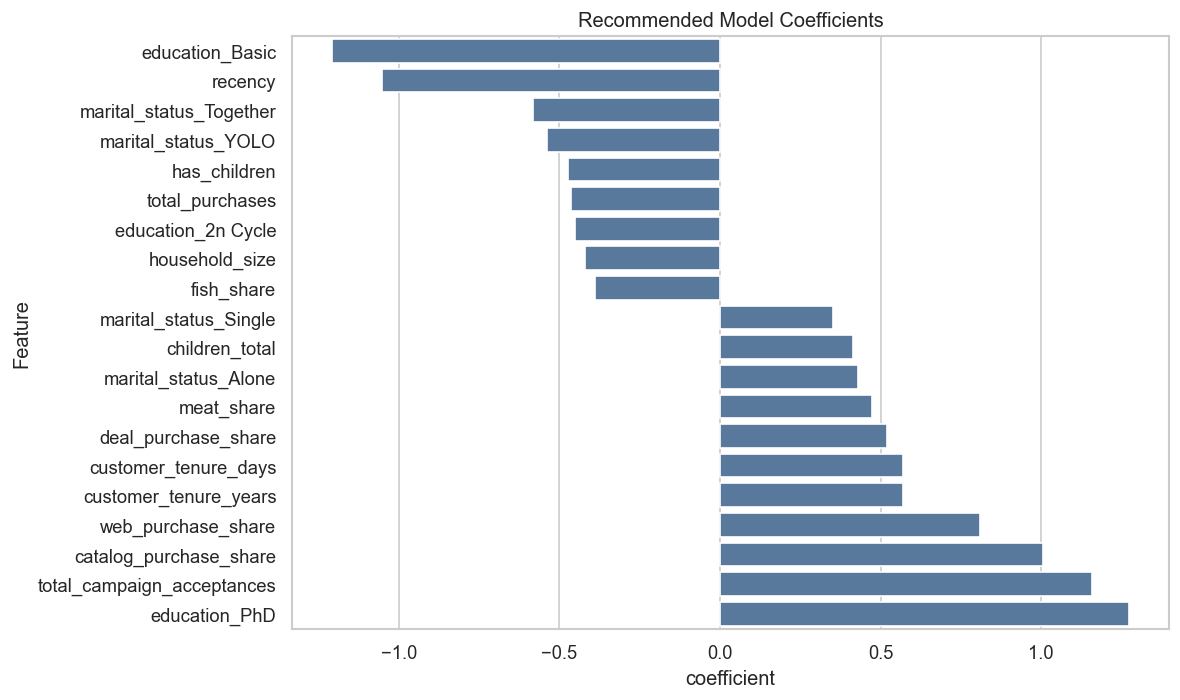

In [16]:
# Save a concise interpretability figure for the recommended model.
recommended_interpretation = interpretation_tables[preferred_feature_set].copy()

if "coefficient" in recommended_interpretation.columns:
    plot_data = recommended_interpretation.sort_values("coefficient")
    x_col = "coefficient"
    title = "Recommended Model Coefficients"
else:
    plot_data = recommended_interpretation.sort_values("importance")
    x_col = "importance"
    title = "Recommended Model Feature Importances"

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_data, y="feature", x=x_col, ax=ax, color="#4C78A8")
ax.set_title(title)
ax.set_xlabel(x_col)
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "recommended_model_interpretability.png", bbox_inches="tight")
plt.show()

**Interpretability notes:** The best Feature Set B model gives the cluster one-hot features effectively zero importance, which supports the metric comparison: clusters did not add predictive value beyond the original customer features. In Feature Set C, `total_campaign_acceptances` is one of the strongest coefficients, indicating that prior campaign behavior is useful for prediction. Cluster coefficients in the full model are much smaller than the campaign-history coefficient.

## 11. Final Recommendation and Limitations

**Recommended model for this project step:** Feature Set C with Logistic Regression Balanced.

Reasons:

- Best PR-AUC among the tested combinations.
- Strong recall for the minority response class.
- Interpretable coefficients.
- Uses the same leakage-controlled pipeline structure as the other models.

**Answer to the cluster research question:** Adding the `cluster` feature did not improve performance from Feature Set A to Feature Set B. The cluster label is useful for segmentation and interpretation, but in this controlled supervised experiment it does not add predictive value beyond the customer features used to create it.

**Limitations and cautions:**

- The dataset is imbalanced, so accuracy should not drive model choice.
- Results are based on one stratified train/test split, not cross-validation.
- Historical campaign features improve prediction but should be used only if the project assumes those campaigns happened before the target campaign.
- Model coefficients and importances are predictive associations, not causal claims.
- No hyperparameter tuning was performed in this step.

## 12. Validation

Confirm that the evaluation summaries and figures were saved.

In [17]:
saved_evaluation = pd.read_csv(MODEL_EVALUATION_PATH)
saved_feature_comparison = pd.read_csv(FEATURE_SET_COMPARISON_PATH)
saved_figures = sorted(path.name for path in FIGURE_DIR.glob("*model*.png")) + sorted(path.name for path in FIGURE_DIR.glob("feature_set_*.png")) + sorted(path.name for path in FIGURE_DIR.glob("threshold_*.png"))

print(f"Saved model evaluation shape: {saved_evaluation.shape}")
print(f"Saved feature-set comparison shape: {saved_feature_comparison.shape}")
print("Saved model evaluation figures:")
for figure in sorted(set(saved_figures)):
    print(f"- {figure}")

assert saved_evaluation.shape[0] == len(FEATURE_SETS) * 6
assert saved_feature_comparison.shape[0] == len(FEATURE_SETS)

Saved model evaluation shape: (18, 13)
Saved feature-set comparison shape: (3, 9)
Saved model evaluation figures:
- best_models_roc_pr_curves.png
- feature_set_comparison_metrics.png
- model_comparison_pr_auc_f1.png
- recommended_model_confusion_matrix.png
- recommended_model_interpretability.png
- threshold_analysis_recommended_model.png
